# Intro
Purpose:

    Make some plots of the PACE-PAX aerosol from the Twin Otter (TO)

Input:

    None

Output:

    Figure and save files

Keywords:

    none

Dependencies:
  - load_utils.py
  - matplotlib
  - numpy
  - write_utils
  - path_utils

Needed Files:
  - NA
  - ...

Modification History:

    Written: Samuel LeBlanc, Santa Cruz, CA, 2025-07-29
    Modified:

# Prepare python environment

In [1]:
import numpy as np
#import Sp_parameters as Sp
import load_utils as lu
import write_utils as wu
from path_utils import getpath
import matplotlib.pyplot as plt
%matplotlib inline
import os
import pandas as pd
from datetime import datetime

In [2]:
name = 'PACEPAX_TO'
vv = 'v0'
fp = getpath(name)

Return path named:  PACEPAX_TO C:\Users\sleblan2\OneDrive - NASA\PACE-PAX_personal\data\TO\


# Load files

In [3]:
f = os.listdir(fp)
f.sort()
f

['PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240903_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240904_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240906_R0_L1.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240906_R0_L2.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240907_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240908_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240912_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240913_R0_L1.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240913_R0_L2.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240919_R0_L1.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240919_R0_L2.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240920_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240922_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240923_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240924_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240926_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240927_R0.ic

In [4]:
metnav = {}
for fn in f:
    if (fn.endswith('.ict') & ('MetNav' in fn)): 
        daystr = fn.split('_')[2] 
        if len(fn.split('_'))>4: daystr = daystr +'_'+ fn.split('_')[4].split('.')[0]
        print('doing : '+daystr)

        metnav[daystr] = lu.load_ict(os.path.join(fp,fn))

doing : 20240829
('Time_Start', 'Latitude', 'Longitude', 'GPS_Altitude', 'Pressure_Altitude', 'Radar_Altitude', 'Pitch_Angle', 'Roll_Angle', 'True_Heading', 'True_Air_Speed', 'East_Vel_Aircraft', 'North_Vel_Aircraft', 'Up_Vel_Aircraft', 'Press_Ambient', 'Temp_Ambient', 'Temp_DewPoint', 'Relative_Humidity_Ambient', 'Potential_Temp', 'Equivalent_Potential_Temp', 'Virtual_Potential_Temp', 'Virtual_Temp', 'Wind_Speed', 'Wind_Direction', 'Vert_WindSpeed', 'H2OMR', 'SPHum', 'PSA_PVM', 'LWC_PVM', 'Re_PVM', 'IRT_Nad', 'SPNT', 'SPND', 'UF_CPC_3025', 'PCASP', 'CASF_DNCN', 'CASF_Vol', 'CIP_DNCN', 'CIP_Vol', 'LWC_Wire')
doing : 20240904
('Time_Start', 'Latitude', 'Longitude', 'GPS_Altitude', 'Pressure_Altitude', 'Radar_Altitude', 'Pitch_Angle', 'Roll_Angle', 'True_Heading', 'True_Air_Speed', 'East_Vel_Aircraft', 'North_Vel_Aircraft', 'Up_Vel_Aircraft', 'Press_Ambient', 'Temp_Ambient', 'Temp_DewPoint', 'Relative_Humidity_Ambient', 'Potential_Temp', 'Equivalent_Potential_Temp', 'Virtual_Potential_Te

In [5]:
aer = {}
for fn in f:
    if (fn.endswith('.ict') & ('MICROPHYSICAL' in fn)): 
        daystr = fn.split('_')[2] 
        if len(fn.split('_'))>4: daystr = daystr +'_'+ fn.split('_')[4].split('.')[0]
        print('doing : '+daystr)

        aer[daystr] = lu.load_ict(os.path.join(fp,fn))

doing : 20240903
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
doing : 20240904
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
doing : 20240906_L1
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
doing : 20240906_L2
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
doing : 20240907
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
doing : 20240908
('Time_Mid', 'Int

# Plot out the different values

## Interpolate the alt, lat, lon to the aerosol values

In [6]:
from scipy.interpolate import interp1d
def inter(xold,yold,xnew):
    igood = np.isfinite(xold) & np.isfinite(yold)
    fx = interp1d(xold[igood],yold[igood],fill_value="extrapolate")
    return fx(xnew)

In [7]:
import numpy.lib.recfunctions as rfn

In [8]:
aern = {}
for k in list(aer.keys()):
    if not k in metnav: continue
    print(k)
    aern[k] = {}
    for ko in ['Latitude', 'Longitude', 'GPS_Altitude']:
        aern[k][ko] = inter(metnav[k]['Time_Start'],metnav[k][ko],aer[k]['Time_Mid'].data)
        #aer[k] = rfn.append_fields(aer[k],ko,inter(metnav[k]['Time_Start'],metnav[k][ko],aer[k]['Time_Mid'].data),dtypes='<f8')

20240904
20240906_L1
20240906_L2
20240907
20240908
20240912
20240913_L1
20240913_L2
20240919_L1
20240919_L2
20240920
20240922
20240923
20240924
20240926
20240927


## plot the aerosol number per alt

In [9]:
aer[k]

array([(73627., 800.24, 73.52, 2.78, 3.33, 53.91, 37.5 , 1.093),
       (73628., 787.34, 72.47, 2.86, 4.  , 86.9 , 63.57, 1.092),
       (73629., 758.66, 75.15, 3.18, 2.61, 39.98, 23.36, 1.092), ...,
       (84682., 401.4 , 45.42, 2.15, 3.43, 29.88, 11.85, 1.088),
       (84683., 384.72, 48.21, 2.41, 4.31, 30.49, 10.16, 1.087),
       (84684., 358.08, 40.27, 1.76, 3.92, 30.36, 10.09,   nan)],
      shape=(11058,), dtype=[('Time_Mid', '<f8'), ('IntegN_100to1000nm_UHSAS', '<f8'), ('IntegS_100to1000nm_UHSAS', '<f8'), ('IntegV_100to1000nm_UHSAS', '<f8'), ('IntegN_gt1000nm_APS', '<f8'), ('IntegS_gt1000nm_APS', '<f8'), ('IntegV_gt1000nm_APS', '<f8'), ('stdPT', '<f8')])

In [27]:
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

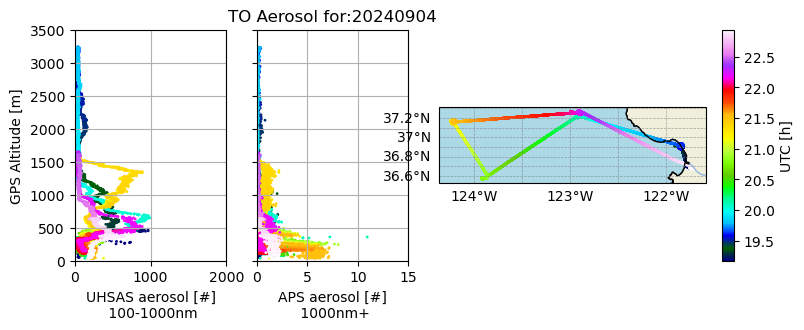

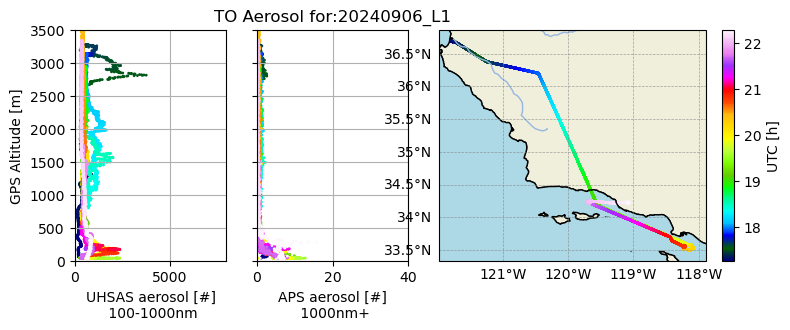

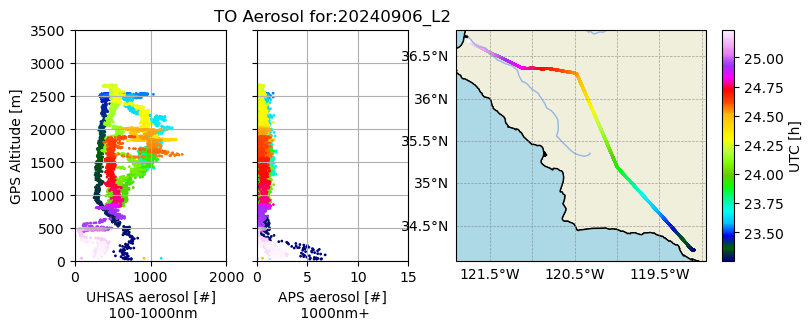

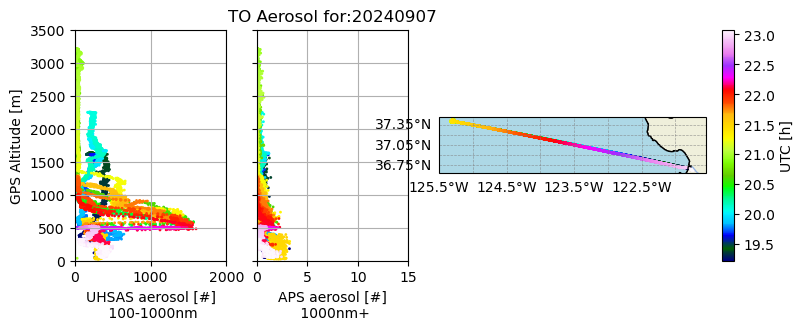

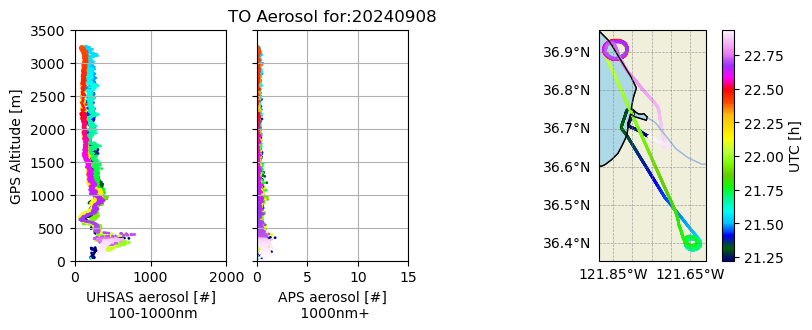

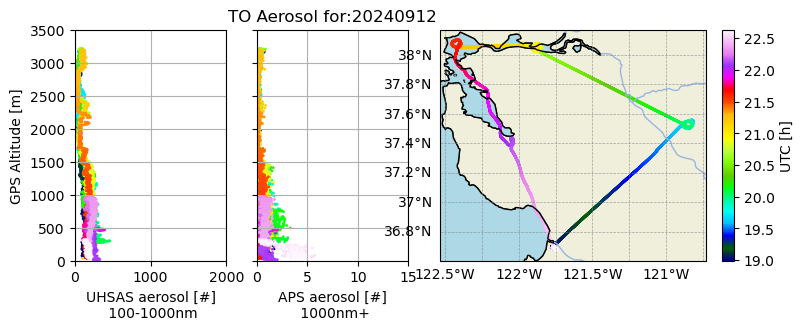

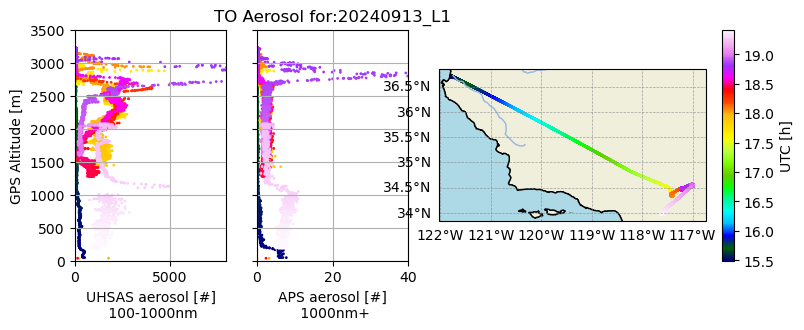

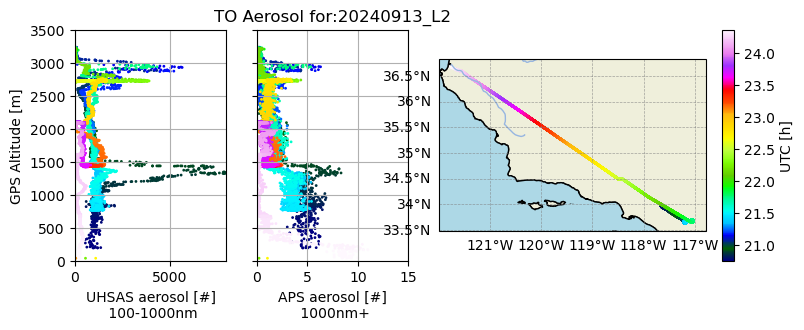

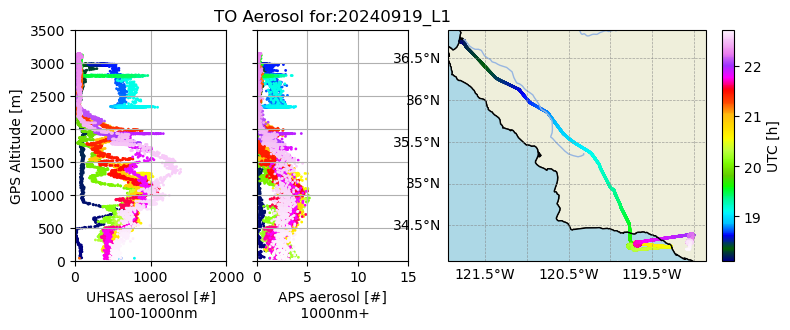

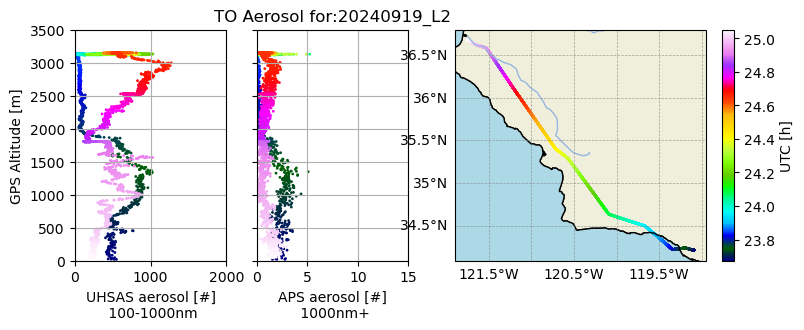

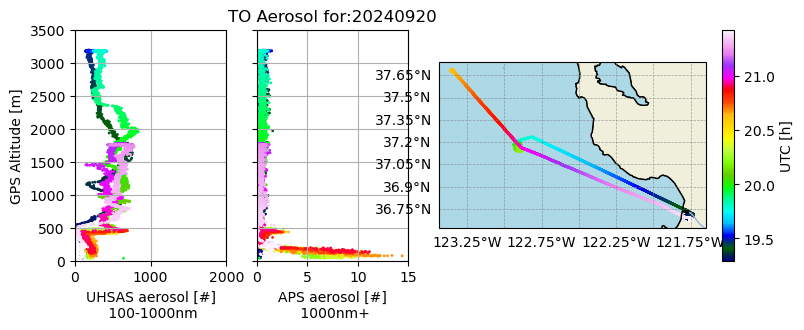

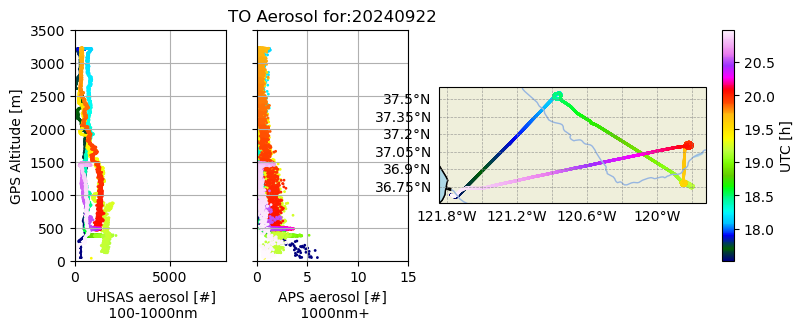

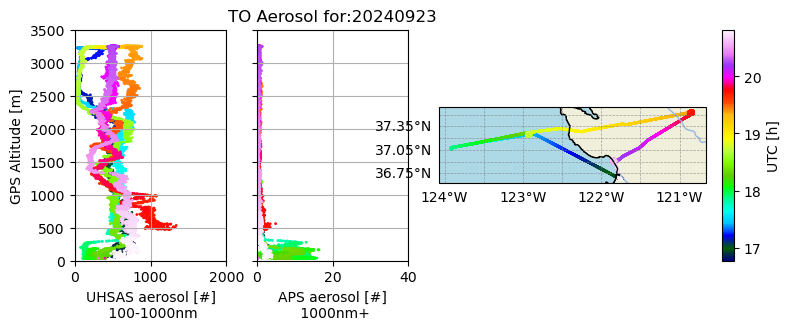

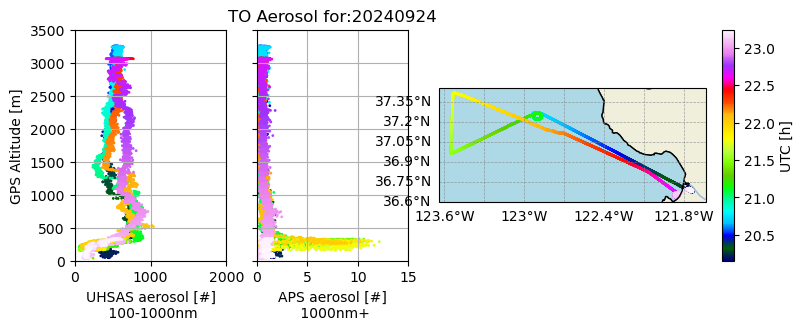

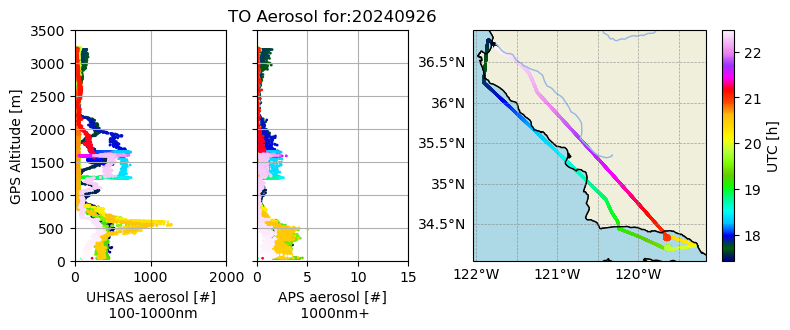

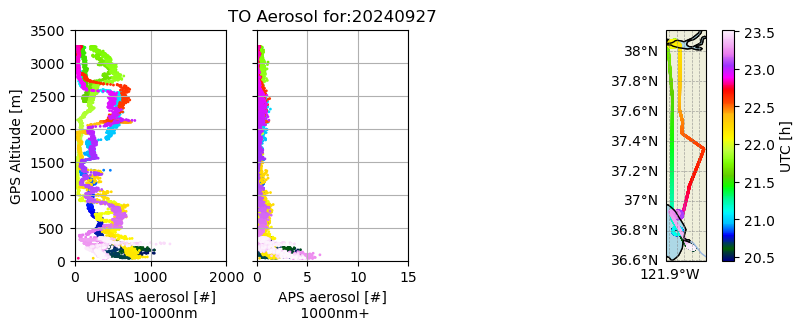

In [40]:
for k in list(aern.keys()):
    #fig,ax = plt.subplots(1,3,figsize=(9,6))
    fig = plt.figure(figsize=(9,3))
    gs = gridspec.GridSpec(1, 4)  # 4 columns to allow spanning
    ax = [fig.add_subplot(gs[0, 0]),fig.add_subplot(gs[0, 1]),fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree())]

    ps =  ax[0].scatter(aer[k]['IntegN_100to1000nm_UHSAS'],aern[k]['GPS_Altitude'],1,c=aer[k]['Time_Mid']/3600.0,cmap='gist_ncar')
    #ax[0].colorbar(ps,label='UTC [h]')
    ax[0].set_xlabel('UHSAS aerosol [#]\n 100-1000nm')
    ax[0].set_ylim(0,3500)
    if max(aer[k]['IntegN_100to1000nm_UHSAS'])>2000: 
        ax[0].set_xlim(0,8000)
    else: 
        ax[0].set_xlim(0,2000)
    ax[0].set_ylabel('GPS Altitude [m]')
    #plt.title('TO Aerosol for:'+k)
    ax[0].grid()

    ps =  ax[1].scatter(aer[k]['IntegN_gt1000nm_APS'],aern[k]['GPS_Altitude'],1,c=aer[k]['Time_Mid']/3600.0,cmap='gist_ncar')
    #ax[0].colorbar(ps,label='UTC [h]')
    ax[1].set_xlabel('APS aerosol [#]\n 1000nm+')
    ax[1].set_ylim(0,3500)
    if max(aer[k]['IntegN_gt1000nm_APS'])>15:
        ax[1].set_xlim(0,40) 
    else:
        ax[1].set_xlim(0,15)
    #ax[1].set_xlim(0,40)
    ax[1].tick_params(labelleft=False)
    #plt.ylabel('GPS Altitude [m]')
    ax[1].set_title('TO Aerosol for:'+k)
    ax[1].grid()

    #ax[2].set_extent([-122.2, -121.75, 36.55, 37.0], crs=ccrs.PlateCarree())

    # Add features
    ax[2].add_feature(cfeature.LAND, zorder=0, edgecolor='black')
    ax[2].add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
    ax[2].add_feature(cfeature.COASTLINE)
    ax[2].add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
    ax[2].add_feature(cfeature.LAKES, facecolor='lightblue')
    ax[2].add_feature(cfeature.RIVERS)
    ps =  ax[2].scatter(aern[k]['Longitude'],aern[k]['Latitude'],1,c=aer[k]['Time_Mid']/3600.0,cmap='gist_ncar')
    plt.colorbar(ps,label='UTC [h]')
    gl = ax[2].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    plt.savefig(os.path.join(fp,'TO_aerosol_num_'+k+'.png'),dpi=600)
    #print('saved to: '+os.path.join(fp,'TO_aerosol_num_'+k+'.png'))
    

In [32]:
fp

'C:\\Users\\sleblan2\\OneDrive - NASA\\PACE-PAX_personal\\data\\TO\\'